# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** Leony Selly Siringo Ringo
- **Email:** leonyselly8@gmail.com
- **ID Dicoding:** leonyselly

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Apa kategori produk yang paling banyak terjual selama tahun 2017?

- Pertanyaan 2: Bagaimana tren jumlah order per bulan selama periode 2017–2018?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [4]:
orders = pd.read_csv('data/orders_dataset.csv')
order_items = pd.read_csv('data/order_items_dataset.csv')
products = pd.read_csv('data/products_dataset.csv')
customers = pd.read_csv('data/customers_dataset.csv')
payments = pd.read_csv('data/order_payments_dataset.csv')
sellers = pd.read_csv('data/sellers_dataset.csv')
reviews = pd.read_csv('data/order_reviews_dataset.csv')

## Insight:

- Dataset terdiri dari beberapa tabel yang saling berhubungan (orders, products, customers, dll) sehingga dapat digabungkan untuk analisis lebih lanjut.

- Setiap dataset memiliki peran berbeda dan akan digunakan sesuai kebutuhan analisis yang relevan dengan pertanyaan bisnis.**Insight:**

### Assessing Data

In [5]:
orders.info()
order_items.info()
products.info()
customers.info()
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

In [6]:
print("Orders:\n", orders.isna().sum(), "\n")
print("Order Items:\n", order_items.isna().sum(), "\n")
print("Products:\n", products.isna().sum(), "\n")
print("Customers:\n", customers.isna().sum(), "\n")
print("Payments:\n", payments.isna().sum(), "\n")

Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 

Order Items:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 

Products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64 

Customers:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
cust

In [7]:
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate order_items:", order_items.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())

Duplicate orders: 0
Duplicate order_items: 0
Duplicate products: 0


In [8]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**

- Ditemukan beberapa missing values pada dataset tertentu yang perlu ditangani pada tahap cleaning.

- Tidak ditemukan banyak data duplikat sehingga data relatif konsisten.

- Tipe data pada beberapa kolom (seperti timestamp) masih perlu disesuaikan untuk analisis lebih lanjut.

### Cleaning Data

In [9]:
orders.isna().sum()
products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [10]:
orders.dropna(subset=['order_purchase_timestamp'], inplace=True)

products['product_category_name'].fillna('unknown', inplace=True)

/tmp/ipykernel_2361/2155940258.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna('unknown', inplace=True)


In [11]:
orders.drop_duplicates(inplace=True)
order_items.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)

In [12]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [13]:
df = orders.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(customers, on='customer_id')
df = df.merge(payments, on='order_id')

In [14]:
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

In [15]:
df_2017 = df[df['year'] == 2017]

df_2017_2018 = df[
    (df['order_purchase_timestamp'] >= '2017-01-01') &
    (df['order_purchase_timestamp'] <= '2018-12-31')
]

**Insight:**

- Missing values pada beberapa kolom telah ditangani dengan metode drop dan imputasi sederhana.

- Data duplikat berhasil dihapus sehingga kualitas data lebih terjamin.

- Kolom waktu telah dikonversi ke format datetime untuk mendukung analisis berbasis waktu.

- Dataset telah digabungkan menjadi satu dataframe utama sehingga siap digunakan untuk analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

In [16]:
df['product_category_name'].value_counts().head(10)

,count
product_category_name,
cama_mesa_banho,11823
beleza_saude,9972
esporte_lazer,8945
moveis_decoracao,8744
informatica_acessorios,8082
utilidades_domesticas,7355
relogios_presentes,6201
telefonia,4721
ferramentas_jardim,4574


In [17]:
df['payment_value'].describe()

,payment_value
count,117601.000000
mean,172.686752
std,267.592290
min,0.000000
25%,60.870000
50%,108.210000
75%,189.260000
max,13664.080000


In [18]:
df['year'].value_counts()

,count
year,
2018,63677
2017,53539
2016,385


**Insight:**

- Sebagian besar transaksi terkonsentrasi pada beberapa kategori produk tertentu yang mendominasi penjualan.

- Distribusi nilai pembayaran menunjukkan variasi transaksi, dari pembelian bernilai kecil hingga besar.

- Transaksi didominasi pada tahun tertentu, yang menunjukkan adanya peningkatan aktivitas penjualan pada periode tersebut.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

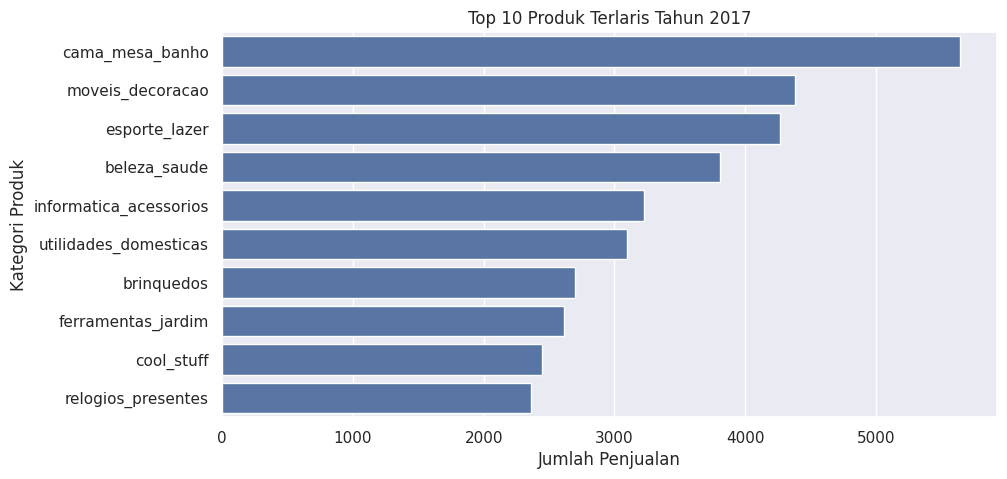

In [19]:
df_2017 = df[df['year'] == 2017]

top_products_2017 = df_2017['product_category_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products_2017.values, y=top_products_2017.index)
plt.title('Top 10 Produk Terlaris Tahun 2017')
plt.xlabel('Jumlah Penjualan')
plt.ylabel('Kategori Produk')
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_2361/935132407.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_range['month_year'] = df_range['order_purchase_timestamp'].dt.to_period('M')


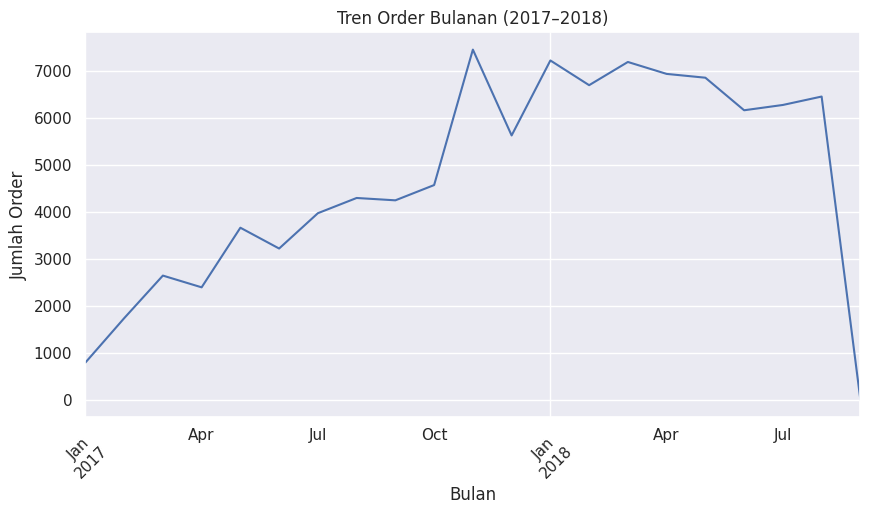

In [20]:
df_range = df[
    (df['order_purchase_timestamp'] >= '2017-01-01') &
    (df['order_purchase_timestamp'] <= '2018-12-31')
]

df_range['month_year'] = df_range['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df_range.groupby('month_year')['order_id'].nunique()

plt.figure(figsize=(10,5))
monthly_orders.plot()
plt.title('Tren Order Bulanan (2017–2018)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.show()

**Insight:**

- Tren jumlah order menunjukkan fluktuasi setiap bulan selama periode 2017–2018.

- Terlihat adanya peningkatan pada periode tertentu yang mengindikasikan pola musiman (seasonality).

- Perusahaan dapat memanfaatkan periode dengan tren tinggi untuk meningkatkan promosi dan penjualan.

## Analisis Lanjutan (Opsional)

In [21]:
rfm_df = df.copy()

snapshot_date = rfm_df['order_purchase_timestamp'].max()

rfm = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,292,1,114.74
000161a058600d5901f007fab4c27140,413,1,67.41
0001fd6190edaaf884bcaf3d49edf079,551,1,195.42
0002414f95344307404f0ace7a26f1d5,382,1,179.35
000379cdec625522490c315e70c7a9fb,153,1,107.01


In [22]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

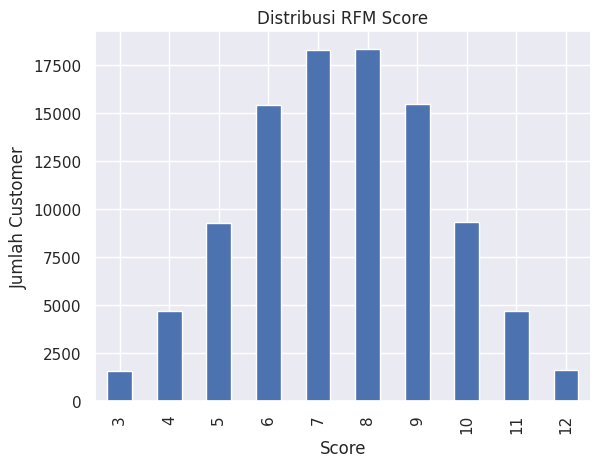

In [23]:
rfm['RFM_score'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribusi RFM Score')
plt.xlabel('Score')
plt.ylabel('Jumlah Customer')
plt.show()

In [24]:
df.to_csv('main_data.csv', index=False)

## Conclusion

## Conclusion

- Kategori produk tertentu menjadi yang paling laris selama tahun 2017, menunjukkan adanya preferensi konsumen pada kategori tersebut.

- Tren order bulanan selama 2017–2018 menunjukkan fluktuasi dengan kecenderungan peningkatan pada periode tertentu, yang mengindikasikan adanya pola musiman dalam perilaku pembelian pelanggan.